In [3]:
import hopsworks
import pandas as pd
import numpy as np

# 1. Connect to Hopsworks Feature Store
project = hopsworks.login()
fs = project.get_feature_store(name='aqi_predictor_fsd_featurestore')
fg = fs.get_feature_group('weather_aqi_hourly', version=6)

# 2. Read dataset via Online Store
df = fg.read(online=True)

# 3. Sort chronologically (Online store returns unsorted records)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['time'].min()} to {df['time'].max()}")

2026-08-21 17:42:41,016 INFO: Initializing external client
2026-08-21 17:42:41,017 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-21 17:42:52,475 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/42119
Dataset shape: (17400, 45)
Date range: 2024-08-24 00:00:00 to 2026-08-18 23:00:00


In [9]:
df.head()

,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,wind_direction_10m,pm2_5,pm10,nitrogen_dioxide,ozone,...,us_aqi_roll_mean_24h,us_aqi_roll_std_24h,us_aqi_roll_min_24h,us_aqi_roll_max_24h,aqi_change_rate_1h,aqi_change_rate_24h,pm25_pm10_ratio,target_aqi_24h,target_aqi_48h,target_aqi_72h
0,2024-08-24 00:00:00,26.5,93,983.4,21.9,48,51.7,83.4,23.1,36.0,...,126.083333,27.770671,98.0,179.0,-0.087687,0.657627,0.619904,150.0,158.0,153.0
1,2024-08-24 01:00:00,28.1,78,982.9,10.7,102,48.9,77.5,21.1,43.0,...,128.125000,27.570167,98.0,179.0,0.057260,0.651757,0.630968,151.0,158.0,151.0
2,2024-08-24 02:00:00,28.5,77,984.0,10.1,86,45.5,72.4,18.3,54.0,...,130.250000,27.190551,98.0,179.0,-0.054159,0.509259,0.628453,151.0,158.0,150.0
3,2024-08-24 03:00:00,29.6,74,984.3,9.0,85,42.3,68.7,15.2,72.0,...,132.458333,26.603333,98.0,179.0,-0.069530,0.358209,0.615720,151.0,159.0,146.0
4,2024-08-24 04:00:00,31.1,69,984.2,10.8,120,40.9,68.7,11.7,103.0,...,134.666667,25.806414,98.0,179.0,-0.070330,0.175000,0.595342,152.0,159.0,143.0


# Data Preprocessing

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17400 entries, 0 to 17399
Data columns (total 45 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  17400 non-null  datetime64[ns]
 1   temperature_2m        17400 non-null  float64       
 2   relative_humidity_2m  17400 non-null  int64         
 3   surface_pressure      17400 non-null  float64       
 4   wind_speed_10m        17400 non-null  float64       
 5   wind_direction_10m    17400 non-null  int64         
 6   pm2_5                 17400 non-null  float64       
 7   pm10                  17400 non-null  float64       
 8   nitrogen_dioxide      17400 non-null  float64       
 9   ozone                 17400 non-null  float64       
 10  us_aqi                17400 non-null  int64         
 11  city                  17400 non-null  object        
 12  wind_u                17400 non-null  float64       
 13  wind_v          

In [12]:
df=df.drop(columns=['city'])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17400 entries, 0 to 17399
Data columns (total 44 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  17400 non-null  datetime64[ns]
 1   temperature_2m        17400 non-null  float64       
 2   relative_humidity_2m  17400 non-null  int64         
 3   surface_pressure      17400 non-null  float64       
 4   wind_speed_10m        17400 non-null  float64       
 5   wind_direction_10m    17400 non-null  int64         
 6   pm2_5                 17400 non-null  float64       
 7   pm10                  17400 non-null  float64       
 8   nitrogen_dioxide      17400 non-null  float64       
 9   ozone                 17400 non-null  float64       
 10  us_aqi                17400 non-null  int64         
 11  wind_u                17400 non-null  float64       
 12  wind_v                17400 non-null  float64       
 13  hour            

In [30]:
df.isna().sum().sum()

np.int64(0)

In [31]:
import pandas as pd

# Select only numeric columns (int, float)
numeric_df = df.select_dtypes(include=['number'])
# Custom aggregate on numeric columns
numeric_metrics = numeric_df.agg(['min', 'max', 'std', 'mean', 'nunique'])
print(numeric_metrics)

         temperature_2m  relative_humidity_2m  surface_pressure  \
min            2.400000              4.000000        969.400000   
max           46.900000            100.000000       1005.500000   
std            8.544813             22.441443          7.039726   
mean          25.318425             58.469253        986.378546   
nunique      429.000000             97.000000        338.000000   

         wind_speed_10m  wind_direction_10m        pm2_5         pm10  \
min            0.000000            1.000000     3.400000     3.400000   
max           38.400000          360.000000   486.200000   804.700000   
std            3.384817           97.716295    67.043822    80.960570   
mean           6.447897          162.960402    83.045483   110.686132   
nunique      227.000000          360.000000  1170.000000  1247.000000   

         nitrogen_dioxide       ozone      us_aqi  ...  us_aqi_roll_mean_24h  \
min              0.000000    0.000000   69.000000  ...             72.541667  

In [ ]:
from sklearn.model_selection import train_test_split



Computing Spearman Correlation across all 43 numeric features...


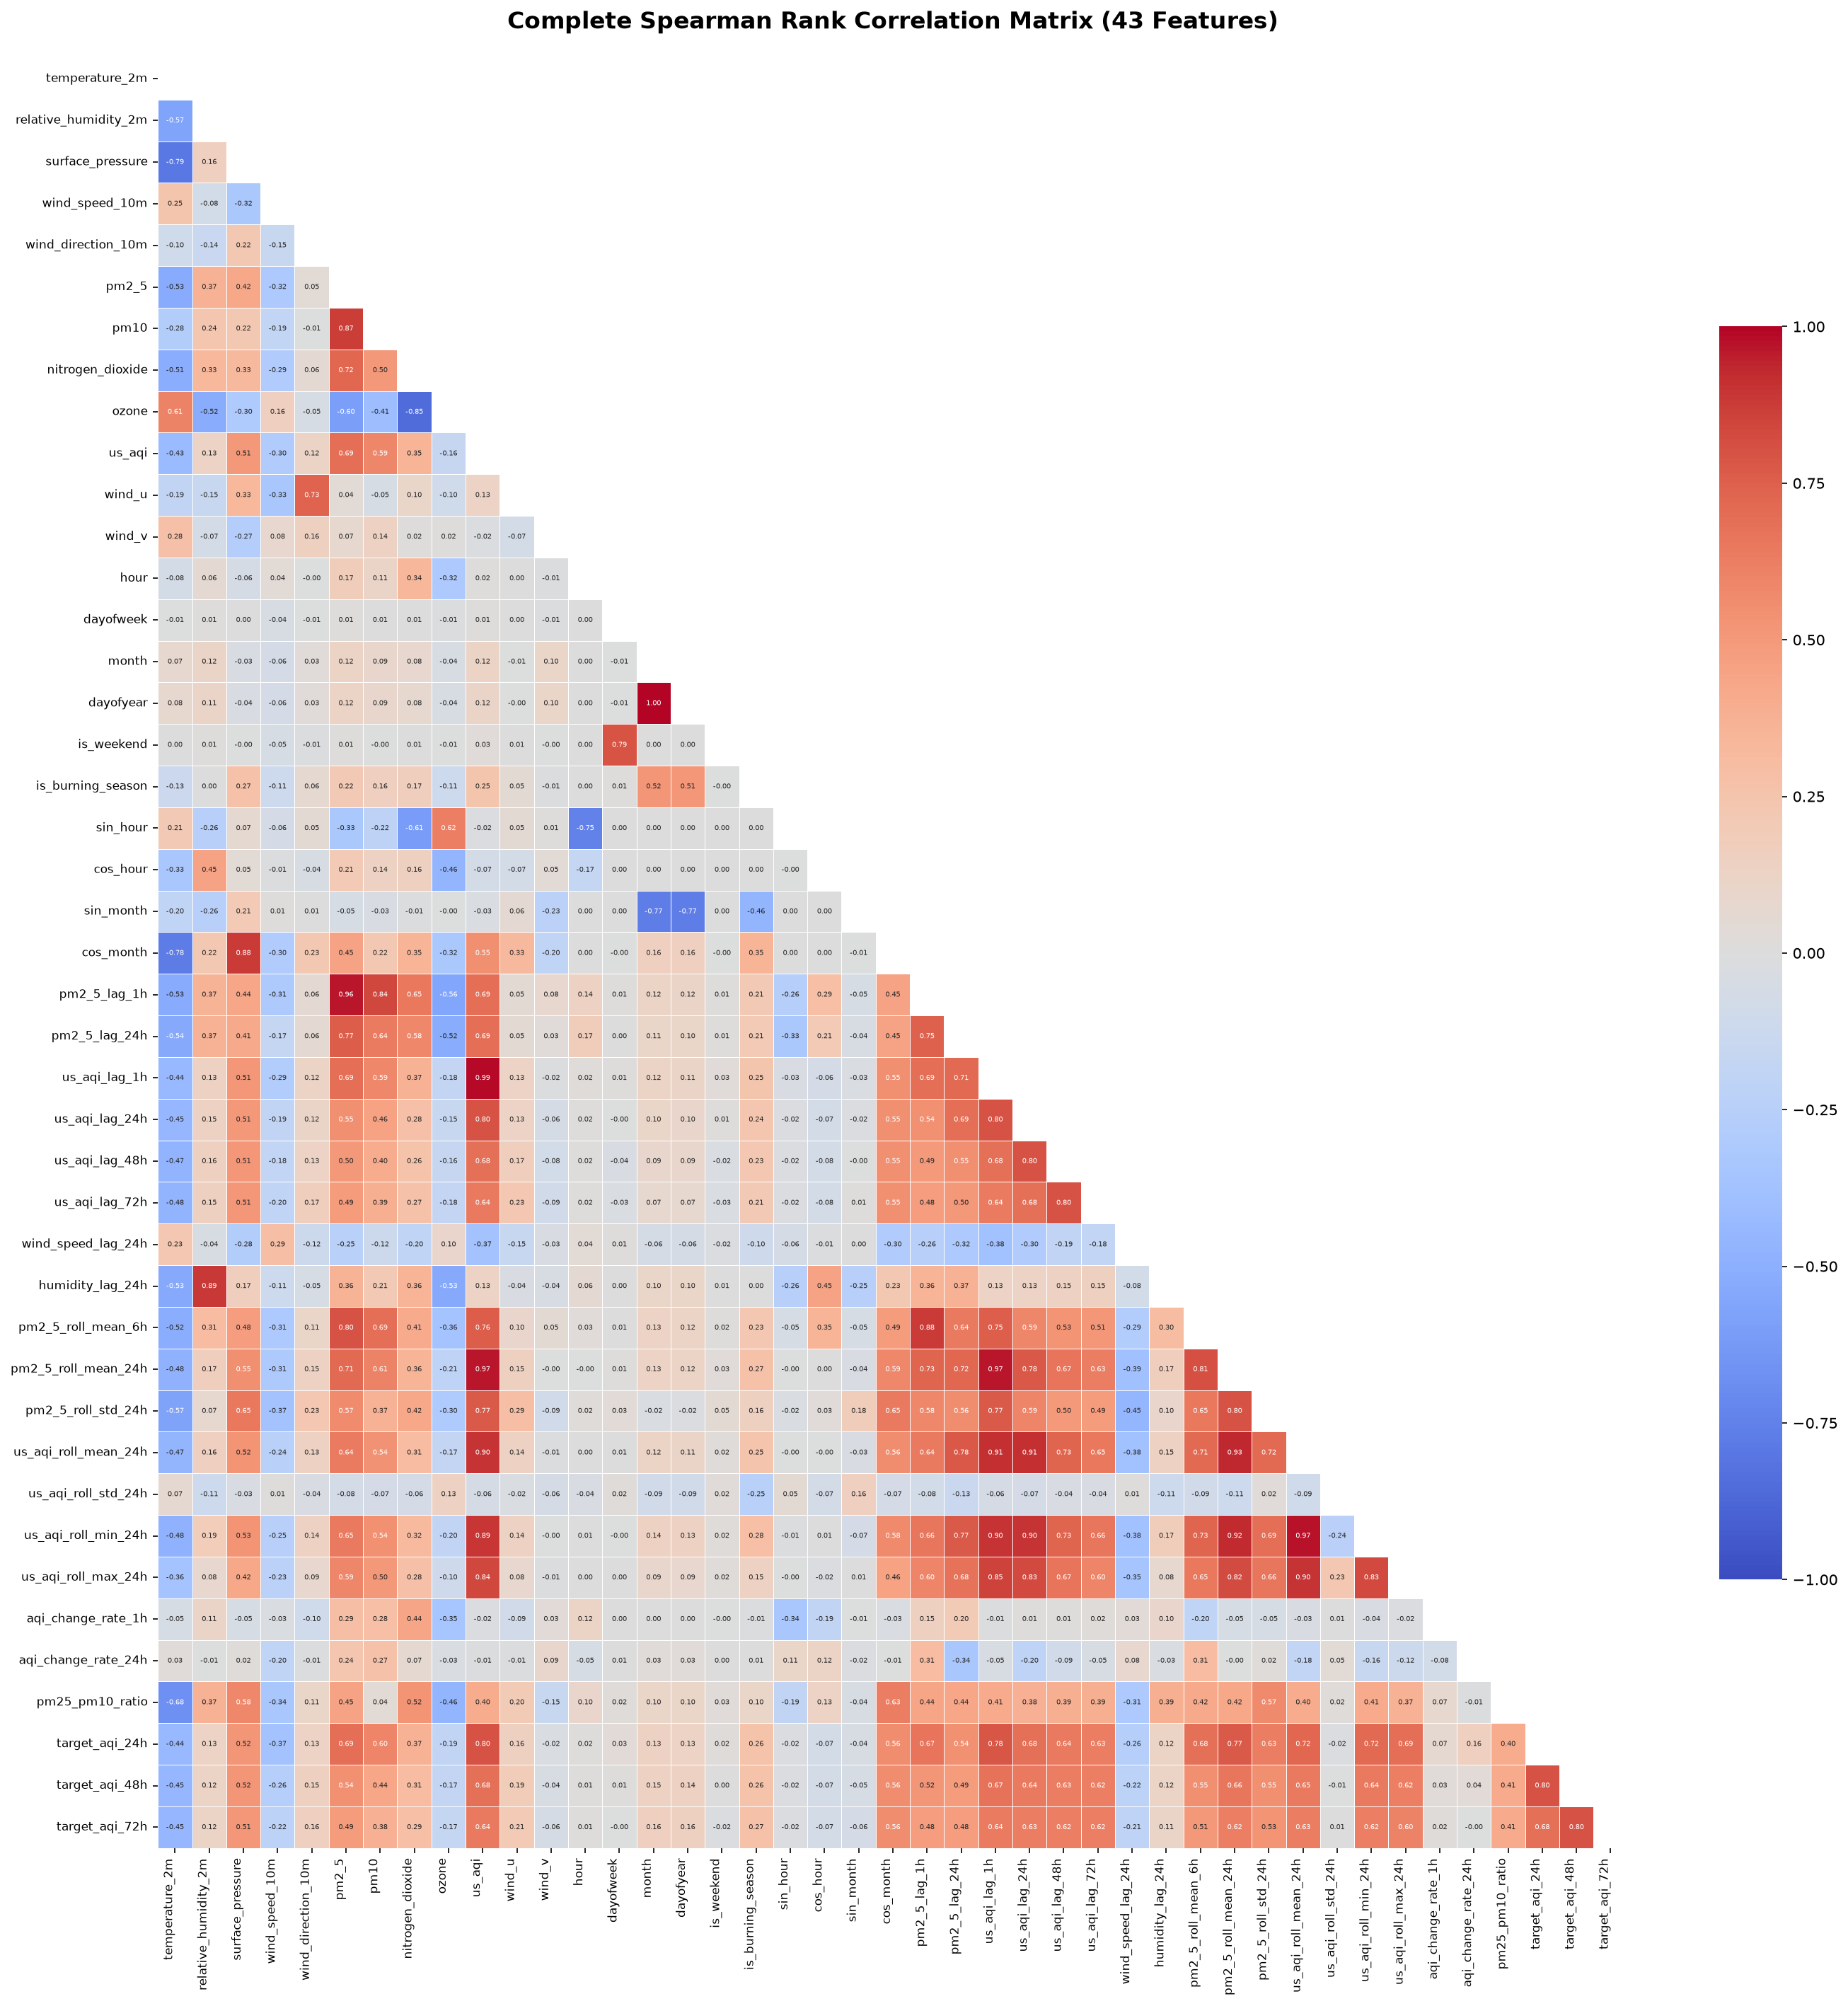

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

print(f"Computing Spearman Correlation across all {numeric_df.shape[1]} numeric features...")

# 3. Compute Full Spearman Rank Correlation
corr_matrix = numeric_df.corr(method="spearman")

# 4. Plot High-Resolution Full Heatmap
# Scale figure size dynamically based on the number of features
num_features = numeric_df.shape[1]
fig_size = max(18, int(num_features * 0.45))

plt.figure(figsize=(fig_size, fig_size), dpi=150)

# Mask upper triangle to avoid redundant mirrored data
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot_kws={"size": max(5, 140 // num_features)},  # Auto-scale font size
    cbar_kws={"shrink": 0.7}
)

plt.title(
    f"Complete Spearman Rank Correlation Matrix ({num_features} Features)",
    fontsize=16,
    pad=20,
    weight="bold"
)
plt.xticks(rotation=90, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()


plt.savefig("full_feature_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
# Rank top features driving target_aqi_24h
target_corr = corr_matrix["target_aqi_24h"].abs().sort_values(ascending=False)

print("Top 15 Features Most Correlated with Target AQI (24h):")
print(target_corr.head(16))  # Includes target itself at index 0

Top 15 Features Most Correlated with Target AQI (24h):
target_aqi_24h          1.000000
target_aqi_48h          0.797524
us_aqi                  0.797269
us_aqi_lag_1h           0.784597
pm2_5_roll_mean_24h     0.771666
us_aqi_roll_mean_24h    0.720070
us_aqi_roll_min_24h     0.715935
pm2_5                   0.689379
us_aqi_roll_max_24h     0.688455
pm2_5_roll_mean_6h      0.681169
target_aqi_72h          0.680880
us_aqi_lag_24h          0.680708
pm2_5_lag_1h            0.665127
us_aqi_lag_48h          0.641163
pm2_5_roll_std_24h      0.628905
us_aqi_lag_72h          0.628311
Name: target_aqi_24h, dtype: float64
